<a href="https://colab.research.google.com/github/nourhanelsh/UTM-noice/blob/master/Copy_of_task_2_nourhan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

digit_recognizer_path = kagglehub.competition_download('digit-recognizer')

print('Data source import complete.')


100%|██████████| 15.3M/15.3M [00:01<00:00, 13.6MB/s]

Extracting files...


Data source import complete.


In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from matplotlib import pyplot as plt


In [5]:

import os

# Check the files in the downloaded folder
os.listdir(digit_recognizer_path)

['train.csv', 'sample_submission.csv', 'test.csv']

In [6]:
data = pd.read_csv(os.path.join(digit_recognizer_path, 'train.csv'))
print(data.shape)
data.head()

(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data) # shuffle before splitting into dev and training sets

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [8]:
Y_train

array([9, 2, 3, ..., 0, 5, 7])

Our NN will have a simple two-layer architecture. Input layer 𝑎[0]  will have 784 units corresponding to the 784 pixels in each 28x28 input image. A hidden layer  𝑎[1]  will have 10 units with ReLU activation, and finally our output layer  𝑎[2]  will have 10 units corresponding to the ten digit classes with softmax activation.

Forward propagation

𝑍[1]=𝑊[1]𝑋+𝑏[1]
𝐴[1]=𝑔ReLU(𝑍[1]))
𝑍[2]=𝑊[2]𝐴[1]+𝑏[2]
𝐴[2]=𝑔softmax(𝑍[2])
Backward propagation

𝑑𝑍[2]=𝐴[2]−𝑌
𝑑𝑊[2]=1𝑚𝑑𝑍[2]𝐴[1]𝑇
𝑑𝐵[2]=1𝑚Σ𝑑𝑍[2]
𝑑𝑍[1]=𝑊[2]𝑇𝑑𝑍[2].∗𝑔[1]′(𝑧[1])
𝑑𝑊[1]=1𝑚𝑑𝑍[1]𝐴[0]𝑇
𝑑𝐵[1]=1𝑚Σ𝑑𝑍[1]
Parameter updates

𝑊[2]:=𝑊[2]−𝛼𝑑𝑊[2]
𝑏[2]:=𝑏[2]−𝛼𝑑𝑏[2]
𝑊[1]:=𝑊[1]−𝛼𝑑𝑊[1]
𝑏[1]:=𝑏[1]−𝛼𝑑𝑏[1]
Vars and shapes

Forward prop

𝐴[0]=𝑋 : 784 x m
𝑍[1]∼𝐴[1] : 10 x m
𝑊[1] : 10 x 784 (as  𝑊[1]𝐴[0]∼𝑍[1] )
𝐵[1] : 10 x 1
𝑍[2]∼𝐴[2] : 10 x m
𝑊[1] : 10 x 10 (as  𝑊[2]𝐴[1]∼𝑍[2] )
𝐵[2] : 10 x 1
Backprop

𝑑𝑍[2] : 10 x m (  𝐴[2] )
𝑑𝑊[2] : 10 x 10
𝑑𝐵[2] : 10 x 1
𝑑𝑍[1] : 10 x m (  𝐴[1] )
𝑑𝑊[1] : 10 x 10
𝑑𝐵[1] : 10 x 1

In [9]:
def init_params():
    W1 = np.random.rand(128, 784) -0.5
    b1 = np.random.rand(128, 1) - 0.5

    W3 = np.random.rand(64, 128) -0.5
    b3 = np.random.rand(64, 1) -0.5

    W4 = np.random.rand(32, 64) -0.5
    b4 = np.random.rand(32, 1) -0.5

    W2 = np.random.rand(10, 32) -0.5
    b2 = np.random.rand(10, 1) -0.5
    return W1, b1,W3 ,b3,W4,b4, W2, b2

def GELU(Z):
    # Approximation of GELU
    return 0.5 * Z * (1 + np.tanh(np.sqrt(2/np.pi) * (Z + 0.044715 * Z**3)))

def GELU_deriv(Z):
    # Approximate derivative (simpler version)
    tanh_term = np.tanh(0.0356774*Z**3 + 0.797885*Z)
    return 0.5 * (1 + tanh_term + Z*(1 - tanh_term**2)*(0.107032*Z**2 + 0.398942))

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def forward_prop(W1, b1, W3 ,b3, W4 ,b4, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = Z1
    Z3 = W3.dot(A1) + b3
    A3 = GELU(Z3)
    Z4 = W4.dot(A3) + b4
    A4 = Z4
    Z2 = W2.dot(A4) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z3,A3 ,Z4,A4, Z2, A2


def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z3 ,A3 ,Z4 ,A4 ,Z2, A2, W1,W3, W4 ,W2, X, Y):
    one_hot_Y = one_hot(Y)
    m = X.shape[1]
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A4.T)
    db2 = 1 / m * np.sum(dZ2)

    dZ4 = W2.T.dot(dZ2)
    dW4 = 1 / m * dZ4.dot(A3.T)
    db4 = 1 / m * np.sum(dZ4)

    dZ3 = W4.T.dot(dZ4) * GELU_deriv(Z3)
    dW3 = 1 / m * dZ3.dot(A1.T)
    db3 = 1 / m * np.sum(dZ3)

    dZ1 = W3.T.dot(dZ3)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW3 ,db3 ,dW4 , db4 ,dW2, db2

def update_params(W1, b1,W3 ,b3 ,W4 ,b4 ,W2, b2, dW1, db1,dW3 ,db3 ,dW4 ,db4, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1

    W3 = W3 - alpha * dW3
    b3 = b3 - alpha * db3

    W4 = W4 - alpha * dW4
    b4 = b4 - alpha * db4

    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W3 ,b3 ,W4 ,b4, W2, b2

In [10]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

import time
def gradient_descent(X, Y, alpha, iterations):
    W1, b1,W3, b3, W4, b4, W2, b2 = init_params()
    epoch_times = []
    for i in range(iterations):
        start = time.time()
        Z1, A1, Z3,A3 ,Z4,A4, Z2, A2 = forward_prop(W1, b1, W3 ,b3, W4 ,b4, W2, b2, X)
        dW1, db1, dW3 ,db3 ,dW4 , db4 ,dW2, db2 = backward_prop(Z1, A1, Z3 ,A3 ,Z4 ,A4 ,Z2, A2, W1,W3, W4 ,W2, X, Y)
        W1, b1, W3 ,b3 ,W4 ,b4, W2, b2  = update_params(W1, b1,W3 ,b3 ,W4 ,b4 ,W2, b2, dW1, db1,dW3 ,db3 ,dW4 ,db4, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
        end = time.time()
        epoch_times.append(end - start)
    avg_epoch_time = sum(epoch_times) / len(epoch_times)
    return W1, b1, W3 ,b3, W4, b4, W2, b2,avg_epoch_time

In [11]:
W1, b1, W3 ,b3, W4, b4, W2, b2 , scratch_epoch_time = gradient_descent(X_train, Y_train, 0.01, 500)
print (scratch_epoch_time)

Iteration:  0
[9 2 1 ... 1 3 2] [9 2 3 ... 0 5 7]
0.12670731707317073
Iteration:  10
[9 8 5 ... 4 3 5] [9 2 3 ... 0 5 7]
0.4154390243902439
Iteration:  20
[8 8 3 ... 4 5 5] [9 2 3 ... 0 5 7]
0.5324634146341464
Iteration:  30
[8 8 3 ... 4 5 5] [9 2 3 ... 0 5 7]
0.6003414634146341
Iteration:  40
[8 8 3 ... 0 5 5] [9 2 3 ... 0 5 7]
0.641219512195122
Iteration:  50
[8 8 3 ... 0 5 2] [9 2 3 ... 0 5 7]
0.6718780487804878
Iteration:  60
[8 8 3 ... 0 5 2] [9 2 3 ... 0 5 7]
0.6943170731707317
Iteration:  70
[8 8 3 ... 0 5 2] [9 2 3 ... 0 5 7]
0.711390243902439
Iteration:  80
[8 8 3 ... 0 3 2] [9 2 3 ... 0 5 7]
0.7255853658536585
Iteration:  90
[8 8 3 ... 0 3 2] [9 2 3 ... 0 5 7]
0.7364146341463415
Iteration:  100
[8 8 3 ... 0 3 2] [9 2 3 ... 0 5 7]
0.7477560975609756
Iteration:  110
[8 8 3 ... 0 3 2] [9 2 3 ... 0 5 7]
0.7563414634146342
Iteration:  120
[8 8 3 ... 0 3 2] [9 2 3 ... 0 5 7]
0.7632439024390244
Iteration:  130
[8 8 3 ... 0 3 2] [9 2 3 ... 0 5 7]
0.7694878048780488
Iteration:  140
[8

In [12]:
def make_predictions(X,  W1, b1,W3 ,b3 ,W4 ,b4, W2, b2):
    _, _,_,_,_,_,_, A2 = forward_prop( W1, b1,W3 ,b3 ,W4 ,b4, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index,  W1, b1,W3 ,b3 ,W4 ,b4, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None],  W1, b1,W3 ,b3 ,W4 ,b4, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

examples output

Prediction:  [9]
Label:  9


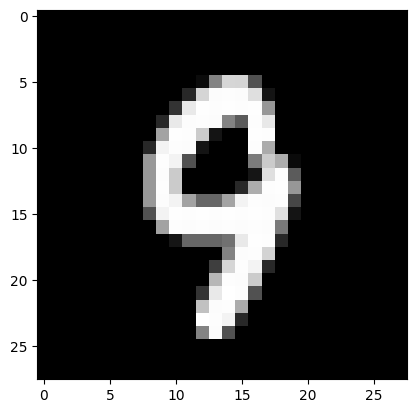

Prediction:  [2]
Label:  2


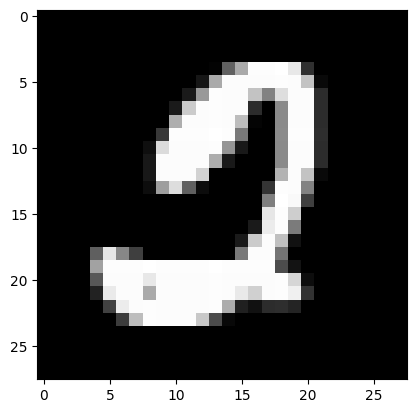

Prediction:  [3]
Label:  3


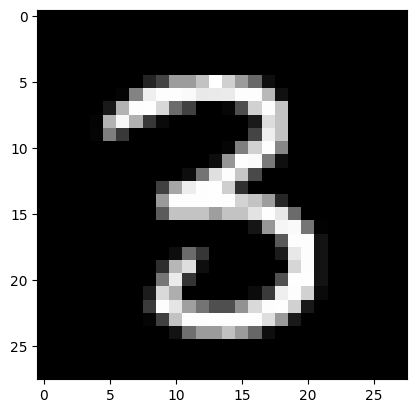

Prediction:  [1]
Label:  1


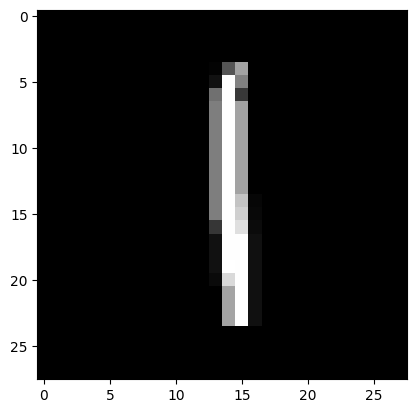

In [13]:
test_prediction(0, W1, b1,W3 ,b3 ,W4 ,b4, W2, b2)
test_prediction(1,  W1, b1,W3 ,b3 ,W4 ,b4, W2, b2)
test_prediction(2, W1, b1,W3 ,b3 ,W4 ,b4, W2, b2)
test_prediction(3,  W1, b1,W3 ,b3 ,W4 ,b4, W2, b2)

find accuracy

In [14]:
dev_predictions = make_predictions(X_dev, W1, b1,W3 ,b3,W4,b4, W2, b2)
accuracy = get_accuracy(dev_predictions, Y_dev)
print(f"Development set accuracy: {accuracy*100:.2f}%")

[2 6 3 2 1 9 4 0 9 4 6 0 1 4 6 3 7 8 7 4 2 8 8 3 4 8 3 2 1 6 9 3 6 7 7 2 1
 7 0 9 0 8 7 1 3 8 6 9 9 5 8 3 6 6 2 3 9 4 1 5 1 7 4 4 6 7 2 0 7 3 8 6 9 2
 5 0 9 0 7 6 2 7 8 5 9 7 3 1 8 7 6 0 1 1 6 7 3 9 2 2 5 4 3 2 0 4 5 7 3 5 2
 2 0 7 5 7 3 2 6 0 8 3 7 3 0 2 4 7 7 1 1 8 1 6 6 8 5 0 6 6 2 0 1 3 8 0 1 7
 9 1 3 5 8 2 3 4 6 1 3 9 2 6 7 6 2 8 7 0 3 2 7 4 1 4 4 2 2 6 1 7 6 7 6 0 2
 5 1 5 6 1 6 5 4 4 6 1 7 8 3 1 4 4 0 7 5 2 9 4 0 6 9 9 2 1 6 4 8 9 9 7 0 6
 2 5 9 4 6 4 1 6 0 0 4 3 4 3 2 4 2 8 5 6 5 7 5 4 1 1 9 8 8 3 9 8 2 6 2 5 0
 0 0 0 1 1 2 5 7 2 9 2 4 9 7 7 1 9 6 4 0 2 8 1 5 8 7 9 1 6 5 9 5 9 5 9 4 8
 6 1 4 7 4 7 3 6 2 4 7 5 8 0 3 5 7 0 7 6 1 4 0 8 1 2 2 1 0 0 1 5 8 5 6 4 7
 0 2 4 2 0 6 4 9 7 7 6 2 8 3 6 1 7 3 5 7 0 2 8 4 7 2 2 2 1 2 5 5 4 1 6 4 4
 5 1 3 1 1 7 7 3 2 5 3 3 2 0 7 3 4 9 2 1 8 4 9 4 1 9 0 0 8 5 6 3 4 2 3 6 1
 4 3 0 0 6 3 5 1 8 2 2 1 2 1 6 5 8 4 3 9 5 1 8 8 4 9 7 2 2 4 9 4 1 7 7 4 2
 5 2 9 8 6 8 6 6 4 9 0 9 0 1 0 5 1 7 1 3 4 2 8 6 5 2 3 2 7 1 3 3 6 7 7 4 9
 9 0 6 3 8 4 0 9 0 4 3 0 

confusion matrix

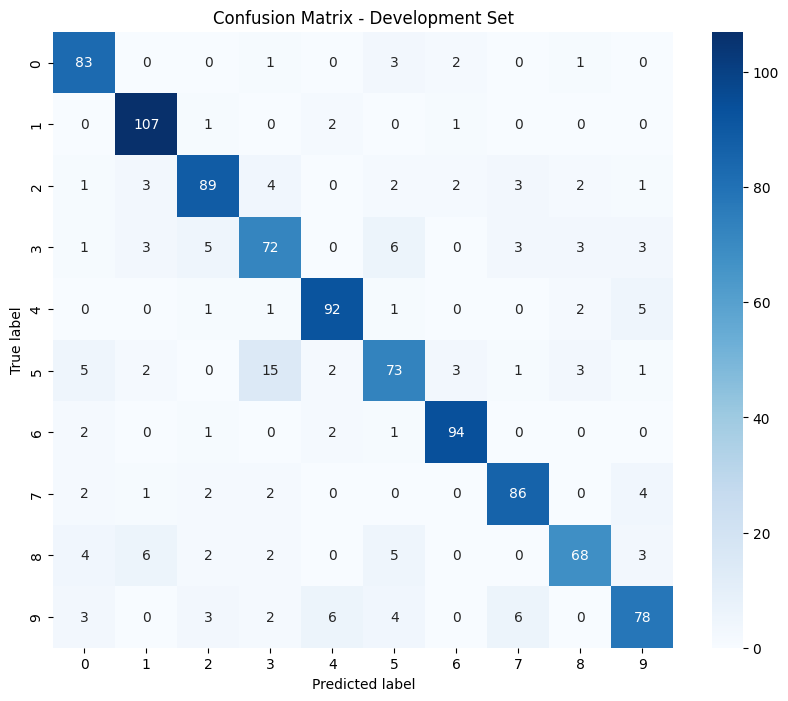

In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(Y_dev, dev_predictions)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Development Set")
plt.show()

identify mismatches

In [16]:

misclassified_idx = np.where(dev_predictions != Y_dev)[0]
print(f"Total misclassified examples: {len(misclassified_idx)}")

Total misclassified examples: 158


define flaws


In [17]:
penmanship_similar = {
    (1,7), (7,1),
    (2,7), (7,2),
    (4,9), (9,4),
    (0,9), (9,0)
}

stroke_overlap = {
    (3,8), (8,3),
    (6,8), (8,6),
    (5,3), (3,5),
    (0,8), (8,0)
}

classify function

In [18]:
def classify_failure(true_label, pred_label):
    if (true_label, pred_label) in penmanship_similar:
        return "Penmanship Variance"
    elif (true_label, pred_label) in stroke_overlap:
        return "Stroke Overlap"
    else:
        return "Lack of Training Depth"

display 10 mismatches

Example 1: True=2, Pred=6 → Lack of Training Depth
Example 2: True=5, Pred=4 → Lack of Training Depth
Example 3: True=9, Pred=7 → Lack of Training Depth
Example 4: True=9, Pred=4 → Penmanship Variance
Example 5: True=4, Pred=8 → Lack of Training Depth
Example 6: True=7, Pred=3 → Lack of Training Depth
Example 7: True=2, Pred=7 → Penmanship Variance
Example 8: True=4, Pred=9 → Penmanship Variance
Example 9: True=2, Pred=3 → Lack of Training Depth
Example 10: True=8, Pred=2 → Lack of Training Depth


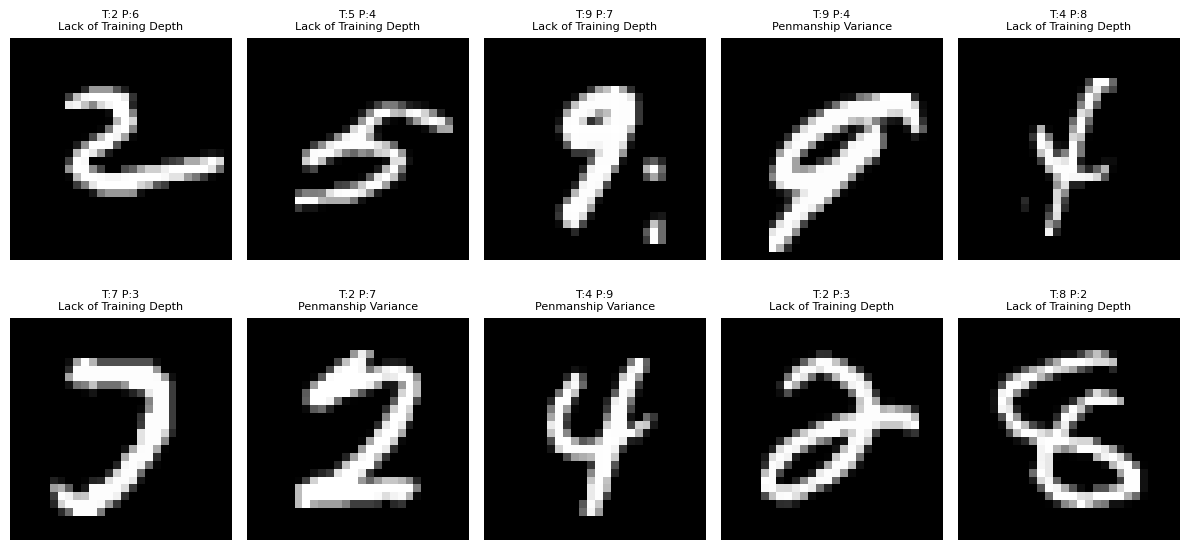

In [19]:
num_to_show = min(10, len(misclassified_idx))
plt.figure(figsize=(12,6))

for i, idx in enumerate(misclassified_idx[:num_to_show]):
    img = X_dev[:, idx].reshape(28,28)
    true_label = Y_dev[idx]
    pred_label = dev_predictions[idx]

    failure_type = classify_failure(true_label, pred_label)

    plt.subplot(2,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"T:{true_label} P:{pred_label}\n{failure_type}", fontsize=8)
    plt.axis('off')

    print(f"Example {i+1}: True={true_label}, Pred={pred_label} → {failure_type}")

plt.tight_layout()
plt.show()

summary of errors

In [20]:
counts = {"Penmanship Variance":0,
          "Stroke Overlap":0,
          "Lack of Training Depth":0}

for idx in misclassified_idx:
    category = classify_failure(Y_dev[idx], dev_predictions[idx])
    counts[category] += 1

print(counts)

{'Penmanship Variance': 20, 'Stroke Overlap': 31, 'Lack of Training Depth': 107}


In [ ]:
!pip install --upgrade tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.activations import gelu  # built-in
import time

tensor flow model

In [27]:


model = keras.Sequential([
    layers.Dense(128, input_shape=(784,)),
    layers.Dense(64, activation='gelu'),
    layers.Dense(32),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.10),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history = model.fit(
    X_train.T, Y_train,
    epochs=50,
    batch_size=32,
    verbose=1
)

end = time.time()

keras_avg_epoch_time = (end - start) / 50

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8561 - loss: 0.4593
Epoch 2/50
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9565 - loss: 0.1409
Epoch 3/50
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9679 - loss: 0.1052
Epoch 4/50
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9740 - loss: 0.0830
Epoch 5/50
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9779 - loss: 0.0687
Epoch 6/50
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9801 - loss: 0.0620
Epoch 7/50
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9818 - loss: 0.0573
Epoch 8/50
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9830 - loss: 0.0506
Epoch 9/50
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9845 - loss: 0.0470
Epoch 10/50
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9872 - loss: 0.0401
Epoch 11/50
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9860 - loss: 0.0432
Epoch 12/50
1282/1282 ━━━━━━━━

In [28]:
dev_loss, dev_accuracy = model.evaluate(X_dev.T, Y_dev, verbose=0)

print("Dev Accuracy:", dev_accuracy)
print("Dev Loss:", dev_loss)

Dev Accuracy: 0.9570000171661377
Dev Loss: 0.5550938844680786


prediction

In [32]:
dev_probabilities = model.predict(X_dev.T)
dev_predictions = np.argmax(dev_probabilities, axis=1)
misclassified_idx = np.where(dev_predictions != Y_dev)[0]

print("Total Misclassified:", len(misclassified_idx))


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step
Total Misclassified: 43


In [33]:
num_to_show = min(10, len(misclassified_idx))

for i in range(num_to_show):
    idx = misclassified_idx[i]
    true_label = Y_dev[idx]
    pred_label = dev_predictions[idx]

    category = classify_failure(true_label, pred_label)

    print(f"Case {i+1}")
    print(f" True Label: {true_label}")
    print(f" Predicted : {pred_label}")
    print(f" Failure Type: {category}")
    print("-" * 40)

Case 1
 True Label: 5
 Predicted : 6
 Failure Type: Lack of Training Depth
----------------------------------------
Case 2
 True Label: 7
 Predicted : 9
 Failure Type: Lack of Training Depth
----------------------------------------
Case 3
 True Label: 3
 Predicted : 2
 Failure Type: Lack of Training Depth
----------------------------------------
Case 4
 True Label: 8
 Predicted : 9
 Failure Type: Lack of Training Depth
----------------------------------------
Case 5
 True Label: 5
 Predicted : 3
 Failure Type: Stroke Overlap
----------------------------------------
Case 6
 True Label: 3
 Predicted : 7
 Failure Type: Lack of Training Depth
----------------------------------------
Case 7
 True Label: 8
 Predicted : 1
 Failure Type: Lack of Training Depth
----------------------------------------
Case 8
 True Label: 4
 Predicted : 9
 Failure Type: Penmanship Variance
----------------------------------------
Case 9
 True Label: 3
 Predicted : 9
 Failure Type: Lack of Training Depth
--------

comparison table

In [34]:

comparison_table = pd.DataFrame({
    "Metric": [
        "Time per Epoch (seconds)",
        "Lines of Code (approx)",
        "Add Extra Layer Effort"
    ],
    "From Scratch": [
        scratch_epoch_time,
        "a lot!",
        "Must modify multiple functions: init_params (weights/biases), forward_prop, backward_prop, update_params"
    ],
    "Keras": [
        keras_avg_epoch_time,
        25,  # approximate model-building lines
        "Simply add one Dense() line; backprop, feedforward, weights handled automatically"
    ]
})
comparison_table

,Metric,From Scratch,Keras
0,Time per Epoch (seconds),1.236209,1.545701
1,Lines of Code (approx),a lot!,25
2,Add Extra Layer Effort,Must modify multiple functions: init_params (w...,"Simply add one Dense() line; backprop, feedfor..."
